1.  Néstor Camilo Peña Guarín
2.  Luis Carlos Taborda Florez
3.  Sebastian Felipe Vargas Quintero
4.  Eliú Alejandro Barrera Martínez

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
recorridos_iniciales= [
    # --- GRUPO 1: REGISTRO Y EMPRENDIMIENTO (EDIFICA) ---
    ["S1", "S2", "S3", "S4", "S5", "S7"], # El decidido: Lee sobre Edifica y se inscribe con éxito.
    ["S1", "S3", "S4", "S5", "S6"],       # El desafortunado: Intento de inscripción directa con error de red.
    ["S1", "S11", "S12", "S3", "S4", "S5", "S7"], # El cauteloso: Investiga quiénes son antes de registrarse.
    ["S1", "S2", "S19", "S3", "S4", "S5", "S7"], # El social: Mira testimonios en redes y luego se inscribe.
    ["S1", "S31", "S3", "S4", "S5", "S7"], # El analítico: Lee políticas primero y luego se registra.
    ["S1", "S21", "S12", "S3", "S4", "S5", "S6"], # El curioso: Lee noticias, se interesa en Edifica, falla el envío.
    ["S1", "S11", "S2", "S34"], # El indeciso: Mira quiénes son, lee sobre emprender y se va.
    ["S1", "S2", "S8", "S10"], # El proactivo: Ve "Quiero emprender" pero prefiere pedir acompañamiento directo.
    ["S1", "S12", "S13", "S14", "S15", "S17"], # El detallista: Quiere saber más de Edifica antes de inscribirse.
    ["S1", "S3", "S4", "S34"], # El que se arrepiente: Empieza a llenar el formulario y cierra la pestaña.

    # --- GRUPO 2: ESTUDIANTES Y AULA VIRTUAL (TU AULA) ---
    ["S1", "S23", "S24", "S25", "S27"], # El estudiante: Acceso directo y exitoso al aula.
    ["S1", "S23", "S24", "S25", "S26"], # El olvidadizo: Error de credenciales al intentar entrar.
    ["S1", "S23", "S28", "S24", "S25", "S27"], # El recuperador: Restablece contraseña y logra entrar.
    ["S1", "S23", "S24", "S25", "S27", "S30", "S34"], # El aplicado: Entra al aula, va a la biblioteca y sale.
    ["S1", "S23", "S24", "S25", "S27", "S29", "S34"], # El curioso: Entra al aula, revisa quiénes son sus mentores y sale.
    ["S1", "S23", "S24", "S25", "S27", "S23", "S34"], # El que revisa y sale: Entra, verifica algo en el aula y sale.
    ["S1", "S21", "S23", "S24", "S25", "S26"], # El distraído: Lee noticias y luego falla al intentar loguearse.
    ["S1", "S23", "S28", "S34"], # El frustrado: Intenta recuperar contraseña pero se rinde y se va.
    ["S1", "S23", "S24", "S25", "S27", "S31", "S34"], # El normativo: Entra al aula, revisa políticas y sale.
    ["S1", "S22", "S23", "S24", "S25", "S27"], # El fan: Mira los Top Speakers y luego entra a estudiar.

    # --- GRUPO 3: EMPRESAS Y CONTACTO CORPORATIVO ---
    ["S1", "S8", "S10"], # El ejecutivo: Necesita acompañamiento empresarial urgente.
    ["S1", "S8", "S9"], # El ejecutivo con mala suerte: Falla al enviar el correo de solicitud.
    ["S1", "S11", "S13", "S14", "S15", "S17"], # El formal: Lee sobre la fundación y envía formulario de contacto.
    ["S1", "S13", "S14", "S15", "S16"], # El interrumpido: Falla al enviar el formulario de más información.
    ["S1", "S22", "S8", "S10"], # El interesado en charlas: Mira speakers y pide acompañamiento.
    ["S1", "S33", "S13", "S14", "S15", "S17"], # El regional: Viene del portal Latam y contacta a la sede local.
    ["S1", "S18", "S13", "S14", "S15", "S17"], # El inspirado: Ve la misión en acción y decide contactar.
    ["S1", "S11", "S29", "S8", "S10"], # El reclutador: Mira mentores y pide acompañamiento para su empresa.
    ["S1", "S12", "S8", "S10"], # El enfocado: Solo quiere Edifica y apoyo empresarial.
    ["S1", "S13", "S34"], # El que se equivoca de botón: Entra a contacto y se sale.

    # --- GRUPO 4: EXPLORACIÓN DE CONTENIDO Y REDES ---
    ["S1", "S21", "S20", "S19", "S34"], # El explorador: Noticias, directorio, testimonios y sale.
    ["S1", "S20", "S11", "S34"], # El buscador de talento: Mira el directorio de emprendedores y quiénes los avalan.
    ["S1", "S22", "S19", "S34"], # El entusiasta de eventos: Mira los shows y luego los testimonios.
    ["S1", "S18", "S21", "S20", "S34"], # El seguidor: Mira la misión, las noticias y el portafolio.
    ["S1", "S32", "S34"], # El filántropo: Va directo a donar y sale de la página.
    ["S1", "S11", "S31", "S34"], # El legalista: Solo quiere saber quiénes son y sus políticas.
    ["S1", "S33", "S34"], # El viajero: Entra y se va directo al portal de Latinoamérica.
    ["S1", "S20", "S34"], # El breve: Solo le interesa ver el portafolio de emprendedores.
    ["S1", "S19", "S18", "S34"], # El visual: Solo ve testimonios y la misión en acción.
    ["S1", "S21", "S34"], # El lector: Solo entra a ver las noticias del día.

    # --- GRUPO 5: COMPORTAMIENTOS HUMANOS COMPLEJOS ---
    ["S1", "S11", "S18", "S22", "S13", "S14", "S15", "S17"], # El que valida todo: Revisa todo el staff y misión antes de escribir.
    ["S1", "S2", "S12", "S3", "S34"], # El que compara: Lee dos secciones de Edifica y no se decide.
    ["S1", "S23", "S24", "S25", "S27", "S30", "S11", "S34"], # El estudiante que busca staff: Estudia y luego mira quiénes son los jefes.
    ["S1", "S32", "S11", "S19", "S34"], # El donante precavido: Mira dónde donar, pero antes valida la reputación.
    ["S1", "S20", "S8", "S10"], # El aliado comercial: Ve emprendedores y pide acompañamiento para ellos.
    ["S1", "S31", "S32", "S34"], # El transparente: Lee políticas de privacidad antes de donar.
    ["S1", "S21", "S22", "S13", "S14", "S15", "S16"], # El frustrado 2: Mira noticias y shows, pero falla al pedir info.
    ["S1", "S29", "S23", "S24", "S25", "S26"], # El alumno perdido: Busca a su mentor pero no puede entrar al aula.
    ["S1", "S18", "S33", "S34"], # El curioso regional: Mira la misión y se va al portal Latam.
    ["S1", "S2", "S20", "S34"], # El observador: Quiere emprender y mira qué están haciendo otros.

    # --- GRUPO 6: RECORRIDOS RÁPIDOS Y VARIADOS ---
    ["S1", "S12", "S34"], # Salida rápida desde Edifica.
    ["S1", "S19", "S7"], # Error lógico (humano): El usuario intenta forzar un estado de éxito sin flujo (poco común pero pasa).
    ["S1", "S11", "S29", "S34"], # Solo quería conocer a los mentores.
    ["S1", "S22", "S34"], # Solo quería ver los Top Speakers.
    ["S1", "S8", "S10"], # Contacto empresarial directo.
    ["S1", "S23", "S28", "S27"], # Recuperación de contraseña y entrada directa.
    ["S1", "S3", "S4", "S5", "S17"], # Error humano de mezcla de formularios (S5 seguido de S17).
    ["S1", "S13", "S14", "S15", "S16"], # Intento fallido de contacto general.
    ["S1", "S31", "S34"], # Solo consulta de términos y condiciones.
    ["S1", "S21", "S11", "S18", "S34"] # El recorrido institucional completo.
]

In [3]:
recorridos = [
    # --- FOCO: CONVERSIÓN DIRECTA (EDIFICA) ---
    ["S1", "S2", "S3", "S4", "S5", "S7"], # El decidido: Inicio -> Emprender -> Registro -> Éxito.
    ["S1", "S3", "S4", "S5", "S6"],       # Fallo técnico en registro directo.
    ["S1", "S11", "S12", "S3", "S4", "S5", "S7"], # Investigar y luego registrarse.
    ["S1", "S12", "S3", "S4", "S5", "S7"], # Interés directo en Edifica y registro.
    ["S1", "S2", "S3", "S4", "S34"],      # Abandono en medio del formulario.
    ["S1", "S21", "S12", "S3", "S4", "S5", "S6"], # Noticias -> Edifica -> Error.
    ["S1", "S11", "S2", "S34"],           # Conoce al equipo y sale.
    ["S1", "S2", "S8", "S10"],            # Emprender -> Pide acompañamiento -> Éxito.
    ["S1", "S12", "S13", "S14", "S15", "S17"], # Consulta general sobre el programa.
    ["S1", "S2", "S12", "S8", "S10"],     # Interés profundo y contacto.

    # --- FOCO: OPERACIÓN EN EL AULA (TU AULA) ---
    ["S1", "S23", "S24", "S25", "S27"],   # Login exitoso.
    ["S1", "S23", "S24", "S25", "S26"],   # Error de credenciales.
    ["S1", "S23", "S28", "S24", "S25", "S27"], # Recuperación de clave y acceso.
    ["S1", "S23", "S24", "S25", "S27", "S30", "S34"], # Acceso a biblioteca y salida.
    ["S1", "S23", "S24", "S25", "S27", "S29", "S34"], # Consulta de mentores y salida.
    ["S1", "S23", "S24", "S25", "S27", "S23", "S34"], # Revisión rápida de panel.
    ["S1", "S21", "S23", "S24", "S25", "S26"], # Mira noticias e intenta loguearse.
    ["S1", "S23", "S28", "S34"],          # No logra recuperar contraseña y sale.
    ["S1", "S22", "S23", "S24", "S25", "S27"], # Mira speakers y entra a estudiar.
    ["S1", "S11", "S23", "S24", "S25", "S27"], # Mira el staff y entra al aula.

    # --- FOCO: CONTACTO EMPRESARIAL Y SOPORTE ---
    ["S1", "S8", "S10"],                  # Solicitud de acompañamiento directa.
    ["S1", "S8", "S9"],                   # Error en envío de correo.
    ["S1", "S11", "S13", "S14", "S15", "S17"], # Institucional -> Contacto.
    ["S1", "S13", "S14", "S15", "S16"],   # Error en formulario de contacto.
    ["S1", "S22", "S8", "S10"],           # Ve charlas y pide apoyo empresarial.
    ["S1", "S33", "S13", "S14", "S15", "S17"], # Tráfico desde Latam -> Contacto.
    ["S1", "S18", "S13", "S14", "S15", "S17"], # Misión en acción -> Contacto.
    ["S1", "S11", "S29", "S8", "S10"],    # Mentores -> Acompañamiento.
    ["S1", "S12", "S8", "S10"],           # Edifica -> Soporte.
    ["S1", "S13", "S34"],                 # Entra a contacto y sale.

    # --- FOCO: EXPLORACIÓN RÁPIDA (REDUCCIÓN S19, S20, S31) ---
    ["S1", "S21", "S11", "S34"],          # Noticias y quiénes somos.
    ["S1", "S18", "S21", "S34"],          # Misión y noticias.
    ["S1", "S22", "S11", "S34"],          # Speakers y fundadores.
    ["S1", "S18", "S21", "S11", "S34"],   # Recorrido institucional corto.
    ["S1", "S32", "S34"],                 # Donación directa.
    ["S1", "S11", "S34"],                 # Solo conócenos.
    ["S1", "S33", "S34"],                 # Salida a Portal Latam.
    ["S1", "S2", "S12", "S34"],           # Mira programa y sale.
    ["S1", "S18", "S34"],                 # Mira misión y sale.
    ["S1", "S21", "S34"],                 # Solo noticias.

    # --- FOCO: RECORRIDOS MIXTOS ---
    ["S1", "S11", "S18", "S22", "S13", "S14", "S15", "S17"],
    ["S1", "S2", "S12", "S3", "S34"],
    ["S1", "S23", "S24", "S25", "S27", "S30", "S11", "S34"],
    ["S1", "S32", "S11", "S34"],
    ["S1", "S11", "S8", "S10"],
    ["S1", "S21", "S22", "S13", "S14", "S15", "S16"],
    ["S1", "S29", "S23", "S24", "S25", "S26"],
    ["S1", "S18", "S33", "S34"],
    ["S1", "S12", "S11", "S34"],
    ["S1", "S21", "S11", "S29", "S34"],

    # --- FOCO: CIERRES RÁPIDOS ---
    ["S1", "S12", "S34"],
    ["S1", "S11", "S29", "S34"],
    ["S1", "S22", "S34"],
    ["S1", "S8", "S10"],
    ["S1", "S23", "S28", "S27"],
    ["S1", "S3", "S4", "S34"],
    ["S1", "S13", "S14", "S15", "S16"],
    ["S1", "S32", "S11", "S34"],
    ["S1", "S21", "S11", "S18", "S34"],
    ["S1", "S2", "S34"]
]

In [4]:
estados = [
    "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10",
    "S11", "S12", "S13", "S14", "S15", "S16", "S17", "S18", "S19", "S20",
    "S21", "S22", "S23", "S24", "S25", "S26", "S27", "S28", "S29", "S30",
    "S31", "S32", "S33", "S34"
]

In [5]:
# Crear matriz inicializada en cero
matriz_conteos = pd.DataFrame(0, index=estados, columns=estados)

# Recorrer todos los recorridos y contar transiciones
for recorrido in recorridos:
    for i in range(len(recorrido) - 1):
        estado_actual   = recorrido[i]
        estado_siguiente = recorrido[i + 1]
        matriz_conteos.loc[estado_actual, estado_siguiente] += 1

matriz_conteos


,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,...,S25,S26,S27,S28,S29,S30,S31,S32,S33,S34
S1,0,7,2,0,0,0,0,3,0,0,...,0,0,0,0,1,0,0,3,2,0
S2,0,0,2,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,2
S3,0,0,0,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
S4,0,0,0,0,5,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
S5,0,0,0,0,0,2,3,0,0,0,...,0,0,0,0,0,0,0,0,0,0
S6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
S7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
S8,0,0,0,0,0,0,0,0,1,8,...,0,0,0,0,0,0,0,0,0,0
S9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
S10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# Dividir cada fila entre su total para obtener probabilidades
matriz_probabilidades = matriz_conteos.div(
    matriz_conteos.sum(axis=1),  # suma por filas
    axis=0                        # aplicar división por filas
).fillna(0)                       # estados sin salidas → 0

matriz_probabilidades


,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,...,S25,S26,S27,S28,S29,S30,S31,S32,S33,S34
S1,0.0,0.116667,0.033333,0.000,0.000000,0.0,0.0,0.050000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.016667,0.0,0.0,0.05,0.033333,0.000000
S2,0.0,0.000000,0.250000,0.000,0.000000,0.0,0.0,0.125000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.250000
S3,0.0,0.000000,0.000000,0.875,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.125000
S4,0.0,0.000000,0.000000,0.000,0.714286,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.285714
S5,0.0,0.000000,0.000000,0.000,0.000000,0.4,0.6,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.000000
S6,0.0,0.000000,0.000000,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.000000
S7,0.0,0.000000,0.000000,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.000000
S8,0.0,0.000000,0.000000,0.000,0.000000,0.0,0.0,0.000000,0.111111,0.888889,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.000000
S9,0.0,0.000000,0.000000,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.000000
S10,0.0,0.000000,0.000000,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.000000


In [7]:
def simular_usuario(matriz_probabilidades, estado_inicial='S1', max_pasos=15):
    estado_actual = estado_inicial
    recorrido     = [estado_actual]
    estados_finales = ["S6", "S7", "S9", "S10", "S16", "S17", "S26", "S27", "S34"]

    for _ in range(max_pasos):
        if estado_actual in estados_finales:
            break                                 # detener si llegó al final

        probabilidades = matriz_probabilidades.loc[estado_actual]

        if probabilidades.sum() == 0:
            break                                 # sin transiciones posibles

        siguiente_estado = np.random.choice(
            matriz_probabilidades.columns,        # lista de estados
            p=probabilidades.values               # pesos de probabilidad
        )
        recorrido.append(siguiente_estado)
        estado_actual = siguiente_estado

    return recorrido


In [8]:
# Simular un usuario
recorrido_simulado = simular_usuario(matriz_probabilidades)

# Mostrar el recorrido
print(" → ".join(recorrido_simulado))


S1 → S12 → S34


In [9]:
resultados = []

for i in range(1000):
    recorrido   = simular_usuario(matriz_probabilidades)
    estado_final = recorrido[-1]

    resultados.append({
        "usuario":      i + 1,
        "recorrido":    " → ".join(recorrido),
        "estado_final": estado_final,
        "num_pasos":    len(recorrido)
    })

df_resultados = pd.DataFrame(resultados)
df_resultados.head()


,usuario,recorrido,estado_final,num_pasos
0,1,S1 → S2 → S12 → S11 → S29 → S23 → S24 → S25 → S27,S27,9
1,2,S1 → S11 → S34,S34,3
2,3,S1 → S23 → S24 → S25 → S27,S27,5
3,4,S1 → S23 → S34,S34,3
4,5,S1 → S23 → S34,S34,3


In [10]:
nombres_estados = {
    "S1": "INICIO",
    "S2": "QUIERO EMPRENDER",
    "S3": "INSCRÍBETE",
    "S4": "LLENAR FORMULARIO DE INSCRIPCIÓN",
    "S5": "ENVIAR FORMULARIO DE INSCRIPCIÓN",
    "S6": "ERROR AL ENVIAR FORMULARIO DE INSCRIPCIÓN",
    "S7": "ÉXITO AL ENVIAR FORMULARIO DE INSCRIPCIÓN",
    "S8": "QUIERO CONOCER MÁS INFORMACIÓN",
    "S9": "ERROR AL ENVIAR CORREO DE MÁS INFO",
    "S10": "ÉXITO AL ENVIAR CORREO DE MÁS INFO",
    "S11": "CONÓCENOS",
    "S12": "PROGRAMA EDIFICA",
    "S13": "CONTÁCTENOS",
    "S14": "LLENAR FORMULARIO DE MÁS INFORMACIÓN",
    "S15": "ENVIAR FORMULARIO DE MÁS INFORMACIÓN",
    "S16": "ERROR AL ENVIAR FORMULARIO DE MÁS INFORMACIÓN",
    "S17": "ÉXITO AL ENVIAR FORMULARIO DE MÁS INFORMACIÓN",
    "S18": "NUESTRA MISIÓN EN ACCIÓN",
    "S19": "VER TESTIMONIOS",
    "S20": "DIRECTORIO DE EMPRENDEDORES",
    "S21": "NOTICIAS",
    "S22": "TOP SPEAKERS",
    "S23": "TU AULA",
    "S24": "LLENAR CREDENCIALES DE INGRESO AL PROGRAMA EDIFICA",
    "S25": "ENVIAR CREDENCIALES",
    "S26": "ERROR DE CREDENCIALES",
    "S27": "ÉXITO DE INGRESO A TU AULA",
    "S28": "REESTABLECER CONTRASEÑA",
    "S29": "MENTORES",
    "S30": "BIBLIOTECA",
    "S31": "POLÍTICAS",
    "S32": "DONACIONES <3",
    "S33": "PORTAL LATINOAMÉRICA COMPARTE",
    "S34": "SALIR"
}

df_resultados["resultado"] = df_resultados["estado_final"].map(nombres_estados)
df_resultados.head()


,usuario,recorrido,estado_final,num_pasos,resultado
0,1,S1 → S2 → S12 → S11 → S29 → S23 → S24 → S25 → S27,S27,9,ÉXITO DE INGRESO A TU AULA
1,2,S1 → S11 → S34,S34,3,SALIR
2,3,S1 → S23 → S24 → S25 → S27,S27,5,ÉXITO DE INGRESO A TU AULA
3,4,S1 → S23 → S34,S34,3,SALIR
4,5,S1 → S23 → S34,S34,3,SALIR


In [11]:
# Frecuencia relativa de cada resultado final (en %)
porcentajes = df_resultados["resultado"].value_counts(normalize=True) * 100

print(porcentajes.round(1))


resultado
SALIR                                            45.0
ÉXITO DE INGRESO A TU AULA                       13.7
ÉXITO AL ENVIAR CORREO DE MÁS INFO               13.7
ÉXITO AL ENVIAR FORMULARIO DE MÁS INFORMACIÓN     7.1
ERROR AL ENVIAR FORMULARIO DE MÁS INFORMACIÓN     5.4
ERROR DE CREDENCIALES                             5.2
ÉXITO AL ENVIAR FORMULARIO DE INSCRIPCIÓN         5.1
ERROR AL ENVIAR FORMULARIO DE INSCRIPCIÓN         2.7
ERROR AL ENVIAR CORREO DE MÁS INFO                2.1
Name: proportion, dtype: float64


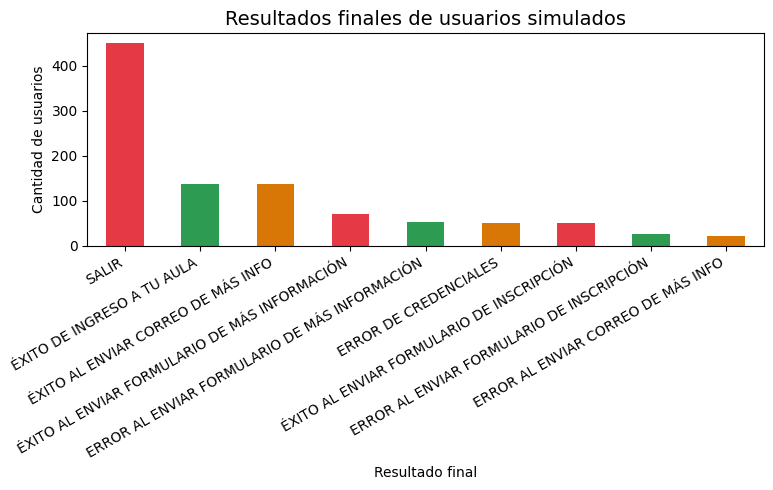

In [12]:
conteo = df_resultados["resultado"].value_counts()

plt.figure(figsize=(8, 5))
conteo.plot(kind='bar', color=['#E63946', '#2D9B51', '#D97706'])
plt.title('Resultados finales de usuarios simulados', fontsize=14)
plt.xlabel('Resultado final')
plt.ylabel('Cantidad de usuarios')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


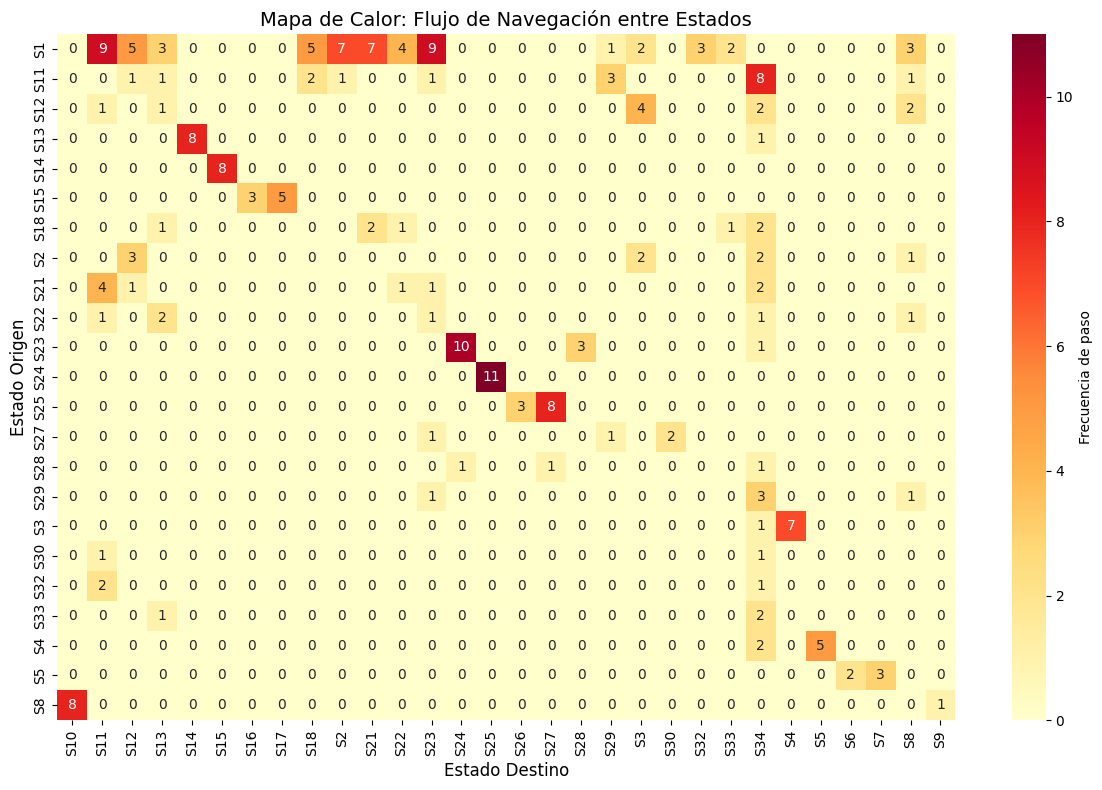

In [13]:
transiciones = []
for camino in recorridos:
    for i in range(len(camino) - 1):
        transiciones.append((camino[i], camino[i+1]))

df_trans = pd.DataFrame(transiciones, columns=['Origen', 'Destino'])
matriz_calor = pd.crosstab(df_trans['Origen'], df_trans['Destino'])

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_calor, annot=True, cmap="YlOrRd", fmt='d', cbar_kws={'label': 'Frecuencia de paso'})

plt.title('Mapa de Calor: Flujo de Navegación entre Estados', fontsize=14)
plt.xlabel('Estado Destino', fontsize=12)
plt.ylabel('Estado Origen', fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
from IPython.display import display, HTML
import json as _json, numpy as _np

# ── Datos frescos ─────────────────────────────────────────────────────────────
_np.random.seed(42)
_res = []
for _i in range(1000):
    _r = simular_usuario(matriz_probabilidades)
    _res.append({'u':_i+1,'path':_r,'final':_r[-1],'steps':len(_r)})

_conteo = {}
for r in _res:
    _conteo[r['final']] = _conteo.get(r['final'],0)+1

_avg = round(sum(r['steps'] for r in _res)/len(_res),2)

_trans = {}
for s in matriz_probabilidades.index:
    row = matriz_probabilidades.loc[s]
    d = {c:round(float(row[c]),4) for c in row.index if row[c]>0}
    if d: _trans[s] = d

_DATA = _json.dumps({
    'nombres': nombres_estados,
    'conteo': _conteo,
    'avg': _avg,
    'trans': _trans,
    'total': 1000
})

_HTML = r"""<!DOCTYPE html><html><head><meta charset="utf-8">
<link href="https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@300;400;500;600;700&family=Orbitron:wght@700;900&display=swap" rel="stylesheet">
<style>
*{box-sizing:border-box;margin:0;padding:0}
:root{
  --bg:#050d18;--bg2:#081422;--card:#0a1a2e;--card2:#0d2040;
  --border:rgba(100,200,255,0.08);--border2:rgba(100,200,255,0.15);
  --gold:#f0a500;--gold2:#ffc841;
  --cyan:#00d4ff;--cyan2:#80eaff;
  --green:#00ff88;--red:#ff4466;--purple:#b388ff;--orange:#ff9944;
  --txt:#c8dff0;--txt2:#5a8099;--txt3:#2a4560;
  --s-inicio:#f0a500;--s-edifica:#ff9944;--s-contacto:#b388ff;
  --s-inst:#00d4ff;--s-aula:#00ff88;--s-exito:#00ff88;--s-error:#ff4466;--s-salida:#5a8099;
}
body{background:transparent;font-family:'Space Grotesk',sans-serif}

/* ROOT */
#ROOT{
  background:var(--bg);
  color:var(--txt);
  border-radius:20px;
  overflow:hidden;
  isolation:isolate;
  border:1px solid var(--border2);
  max-width:1100px;
  margin:0 auto;
  position:relative;
  box-shadow:0 0 80px rgba(0,212,255,0.06), 0 0 200px rgba(0,212,255,0.02);
}
/* Animated background grid */
#ROOT::before{
  content:'';position:absolute;inset:0;
  background-image:
    linear-gradient(rgba(0,212,255,0.03) 1px,transparent 1px),
    linear-gradient(90deg,rgba(0,212,255,0.03) 1px,transparent 1px);
  background-size:40px 40px;
  pointer-events:none;z-index:0;
}
#ROOT>*{position:relative;z-index:1}

/* ── HEADER ── */
.hdr{
  background:linear-gradient(135deg,#06111e 0%,#0a1e34 40%,#06111e 100%);
  border-bottom:1px solid rgba(0,212,255,0.12);
  padding:16px 24px;
  display:flex;align-items:center;justify-content:space-between;
}
.hdr-left{display:flex;align-items:center;gap:14px}
.hdr-orb{
  width:44px;height:44px;border-radius:12px;
  background:linear-gradient(135deg,#f0a500,#ff6600);
  display:flex;align-items:center;justify-content:center;font-size:22px;
  box-shadow:0 4px 20px rgba(240,165,0,0.4);
  animation:orb-pulse 3s ease-in-out infinite;
}
@keyframes orb-pulse{0%,100%{box-shadow:0 4px 20px rgba(240,165,0,0.4)}50%{box-shadow:0 4px 40px rgba(240,165,0,0.7)}}
.hdr-titles{display:flex;flex-direction:column;gap:2px}
.hdr-name{font-family:'Orbitron',sans-serif;font-size:16px;font-weight:900;color:var(--gold2);letter-spacing:1px;line-height:1}
.hdr-sub{font-size:10px;color:var(--txt2);letter-spacing:3px;text-transform:uppercase}
.hdr-right{display:flex;align-items:center;gap:8px}
.badge{font-size:9px;font-weight:600;padding:4px 12px;border-radius:20px;letter-spacing:1.5px;text-transform:uppercase}
.b-markov{background:rgba(240,165,0,0.12);color:var(--gold);border:1px solid rgba(240,165,0,0.25)}
.b-live{background:rgba(0,255,136,0.1);color:var(--green);border:1px solid rgba(0,255,136,0.25);display:flex;align-items:center;gap:5px}
.live-dot{width:6px;height:6px;border-radius:50%;background:var(--green);animation:ldot 1.2s ease-in-out infinite}
@keyframes ldot{0%,100%{opacity:1;transform:scale(1)}50%{opacity:.3;transform:scale(.6)}}

/* ── KPI STRIP ── */
.kpis{
  display:grid;grid-template-columns:repeat(4,1fr);
  gap:1px;background:rgba(0,212,255,0.06);
  border-bottom:1px solid var(--border);
}
.kpi{
  background:var(--bg2);padding:14px 20px;
  display:flex;flex-direction:column;gap:4px;position:relative;overflow:hidden;
}
.kpi::after{content:'';position:absolute;bottom:0;left:0;right:0;height:2px}
.kpi:nth-child(1)::after{background:linear-gradient(90deg,var(--gold),transparent)}
.kpi:nth-child(2)::after{background:linear-gradient(90deg,var(--green),transparent)}
.kpi:nth-child(3)::after{background:linear-gradient(90deg,var(--cyan),transparent)}
.kpi:nth-child(4)::after{background:linear-gradient(90deg,var(--purple),transparent)}
.kpi-val{font-family:'Orbitron',sans-serif;font-size:26px;font-weight:900;line-height:1}
.kpi-lbl{font-size:9px;letter-spacing:2px;color:var(--txt2);text-transform:uppercase}
.kpi-sub{font-size:10px;font-weight:500;margin-top:1px}

/* ── MAIN LAYOUT ── */
.main{display:grid;grid-template-columns:1fr 340px;height:640px}

/* ── FLOW CANVAS ── */
.flow-wrap{
  border-right:1px solid var(--border);
  display:flex;flex-direction:column;
  background:radial-gradient(ellipse at 50% 30%,rgba(0,212,255,0.03),transparent 70%);
}
.flow-toolbar{
  padding:10px 16px;display:flex;align-items:center;justify-content:space-between;
  border-bottom:1px solid var(--border);flex-shrink:0;
}
.flow-title{font-size:9px;letter-spacing:3px;color:var(--cyan);font-weight:600;text-transform:uppercase}
.legend{display:flex;gap:12px;flex-wrap:wrap}
.leg-item{display:flex;align-items:center;gap:4px;font-size:9px;color:var(--txt2)}
.leg-dot{width:7px;height:7px;border-radius:50%}
#flow-canvas{flex:1;width:100%;display:block}

/* ── SIDE PANEL ── */
.side{display:flex;flex-direction:column;overflow:hidden;background:var(--bg2)}

/* current path */
.path-panel{
  padding:14px 16px;border-bottom:1px solid var(--border);flex-shrink:0;
}
.panel-label{font-size:9px;letter-spacing:2.5px;color:var(--cyan);font-weight:600;text-transform:uppercase;margin-bottom:10px;display:flex;align-items:center;gap:6px}
.panel-label::after{content:'';flex:1;height:1px;background:rgba(0,212,255,0.1)}
.path-chips{display:flex;flex-wrap:wrap;gap:3px;min-height:28px;align-items:flex-start;max-height:70px;overflow-y:auto}
.path-chips::-webkit-scrollbar{width:2px}
.path-chips::-webkit-scrollbar-thumb{background:rgba(0,212,255,0.2)}
.chip{font-size:9px;font-weight:700;padding:3px 7px;border-radius:5px;animation:chipIn .15s cubic-bezier(.34,1.56,.64,1)}
@keyframes chipIn{from{transform:scale(0)}to{transform:scale(1)}}
.chip-arr{color:var(--txt3);font-size:9px;line-height:2}
.final-tag{display:inline-flex;align-items:center;gap:5px;font-size:10px;font-weight:700;padding:4px 12px;border-radius:20px;margin-top:8px}
.tag-exit{background:rgba(90,128,153,0.15);color:var(--txt2);border:1px solid rgba(90,128,153,0.25)}
.tag-ok{background:rgba(0,255,136,0.12);color:var(--green);border:1px solid rgba(0,255,136,0.25)}
.tag-err{background:rgba(255,68,102,0.12);color:var(--red);border:1px solid rgba(255,68,102,0.25)}
.path-meta{display:flex;justify-content:space-between;font-size:9px;color:var(--txt3);margin-top:6px}
.path-meta span b{color:var(--txt2)}

/* top results */
.results-panel{padding:12px 16px;border-bottom:1px solid var(--border);flex-shrink:0}
.res-list{display:flex;flex-direction:column;gap:5px}
.res-row{display:flex;align-items:center;gap:8px}
.res-name{font-size:9px;flex:1;white-space:nowrap;overflow:hidden;text-overflow:ellipsis}
.res-track{flex:2;height:4px;background:rgba(255,255,255,0.04);border-radius:2px;overflow:hidden}
.res-fill{height:100%;border-radius:2px;transition:width .6s ease}
.res-pct{font-size:9px;font-weight:700;min-width:36px;text-align:right}

/* log */
.log-panel{flex:1;display:flex;flex-direction:column;overflow:hidden;padding:12px 16px}
.log-scroll{flex:1;overflow-y:auto;display:flex;flex-direction:column;gap:3px}
.log-scroll::-webkit-scrollbar{width:2px}
.log-scroll::-webkit-scrollbar-thumb{background:rgba(0,212,255,0.15)}
.log-row{
  display:flex;align-items:center;gap:6px;padding:4px 8px;
  border-radius:6px;background:rgba(255,255,255,0.02);
  font-size:9px;animation:logIn .15s ease;border:1px solid transparent;
  transition:border-color .2s;
}
.log-row:hover{border-color:rgba(0,212,255,0.15)}
@keyframes logIn{from{opacity:0;transform:translateX(8px)}to{opacity:1;transform:translateX(0)}}
.log-n{font-weight:700;min-width:26px;font-family:'Orbitron',sans-serif;font-size:8px}
.log-path{flex:1;overflow:hidden;text-overflow:ellipsis;white-space:nowrap;color:var(--txt2)}
.log-steps{color:var(--txt3);white-space:nowrap}

/* ── CONTROLS ── */
.controls{
  border-top:1px solid var(--border);
  padding:12px 20px;
  display:flex;gap:8px;align-items:center;
  background:var(--bg);flex-shrink:0;
}
.btn{
  font-family:'Space Grotesk',sans-serif;font-size:11px;font-weight:700;
  padding:10px 18px;border-radius:10px;border:none;cursor:pointer;
  transition:all .15s;letter-spacing:.3px;
}
.btn:active{transform:scale(.96)}
.btn-go{background:linear-gradient(135deg,var(--gold),#c97a10);color:#000;flex:1;box-shadow:0 4px 20px rgba(240,165,0,0.3)}
.btn-go:hover{box-shadow:0 4px 30px rgba(240,165,0,0.5);transform:translateY(-1px)}
.btn-go:disabled{background:rgba(240,165,0,0.15);color:var(--txt3);box-shadow:none;cursor:default;transform:none}
.btn-batch{background:rgba(0,212,255,0.1);color:var(--cyan);border:1px solid rgba(0,212,255,0.2);flex:1}
.btn-batch:hover{background:rgba(0,212,255,0.18)}
.btn-rst{background:rgba(255,255,255,0.04);color:var(--txt2);border:1px solid var(--border)}
.btn-rst:hover{background:rgba(255,255,255,0.08)}
.speed-wrap{display:flex;align-items:center;gap:6px;font-size:10px;color:var(--txt2);white-space:nowrap}
.speed-wrap select{background:var(--card2);color:var(--txt);border:1px solid var(--border2);border-radius:8px;padding:6px 8px;font-size:10px;cursor:pointer}
.est-bar{
  border-top:1px solid var(--border);
  padding:8px 20px;font-size:10px;color:var(--txt2);text-align:center;background:var(--bg);
}
.est-bar b{color:var(--gold);font-weight:600}

/* NODE TOOLTIP */
.tt{
  position:fixed;background:#0a1e34;
  border:1px solid rgba(0,212,255,0.25);border-radius:10px;
  padding:9px 13px;font-size:10px;pointer-events:none;display:none;z-index:99999;
  max-width:220px;box-shadow:0 8px 32px rgba(0,0,0,0.8);backdrop-filter:blur(8px);
  will-change:transform;
}
.tt b{color:var(--cyan2);display:block;margin-bottom:3px;font-size:11px}
.tt-cat{font-size:8px;letter-spacing:1px;text-transform:uppercase;color:var(--txt3);margin-bottom:4px}
.tt-stat{font-size:10px}
</style></head><body>
<div class="tt" id="tt"></div>
<div id="ROOT">

<!-- HEADER -->
<div class="hdr">
  <div class="hdr-left">
    <div class="hdr-orb">🌎</div>
    <div class="hdr-titles">
      <div class="hdr-name">Colombia Comparte</div>
      <div class="hdr-sub">Simulador de flujo · Cadena de Markov</div>
    </div>
  </div>
  <div class="hdr-right">
    <span class="badge b-markov">Markov</span>
    <span class="badge b-live"><span class="live-dot"></span>En vivo</span>
  </div>
</div>

<!-- KPIs -->
<div class="kpis">
  <div class="kpi">
    <div class="kpi-val" style="color:var(--gold)" id="kv1">1 000</div>
    <div class="kpi-lbl">Simulaciones</div>
    <div class="kpi-sub" style="color:var(--green)">✓ Completadas</div>
  </div>
  <div class="kpi">
    <div class="kpi-val" style="color:var(--green)" id="kv2">–</div>
    <div class="kpi-lbl">Salida (S34)</div>
    <div class="kpi-sub" style="color:var(--txt2)">más frecuente</div>
  </div>
  <div class="kpi">
    <div class="kpi-val" style="color:var(--cyan)" id="kv3">–</div>
    <div class="kpi-lbl">Pasos promedio</div>
    <div class="kpi-sub" style="color:var(--txt2)">por recorrido</div>
  </div>
  <div class="kpi">
    <div class="kpi-val" style="color:var(--purple)">34</div>
    <div class="kpi-lbl">Estados</div>
    <div class="kpi-sub" style="color:var(--txt2)">en la cadena</div>
  </div>
</div>

<!-- MAIN -->
<div class="main">

  <!-- FLOW -->
  <div class="flow-wrap">
    <div class="flow-toolbar">
      <span class="flow-title">Mapa de flujo del sitio web</span>
      <div class="legend">
        <div class="leg-item"><div class="leg-dot" style="background:#f0a500"></div>Inicio</div>
        <div class="leg-item"><div class="leg-dot" style="background:#ff9944"></div>Edifica</div>
        <div class="leg-item"><div class="leg-dot" style="background:#b388ff"></div>Contacto</div>
        <div class="leg-item"><div class="leg-dot" style="background:#00d4ff"></div>Institucional</div>
        <div class="leg-item"><div class="leg-dot" style="background:#00ff88"></div>Aula/Éxito</div>
        <div class="leg-item"><div class="leg-dot" style="background:#ff4466"></div>Error</div>
      </div>
    </div>
    <canvas id="flow-canvas"></canvas>
  </div>

  <!-- SIDE -->
  <div class="side">

    <div class="path-panel">
      <div class="panel-label">Recorrido actual</div>
      <div class="path-chips" id="chips">
        <span style="font-size:9px;color:var(--txt3)">Pulsa "Simular usuario" para comenzar</span>
      </div>
      <div id="final-tag"></div>
      <div class="path-meta">
        <span>Pasos: <b id="ps">–</b></span>
        <span>Sim: <b id="sn">–</b></span>
      </div>
    </div>

    <div class="results-panel">
      <div class="panel-label">Top resultados · 1 000 sims</div>
      <div class="res-list" id="res-list"></div>
    </div>

    <div class="log-panel">
      <div class="panel-label">Historial</div>
      <div class="log-scroll" id="log-scroll"></div>
    </div>

  </div>
</div>

<!-- CONTROLS -->
<div class="controls">
  <button class="btn btn-go" id="btn-go" onclick="runOne()">▶ Simular usuario</button>
  <button class="btn btn-batch" onclick="runBatch()">⚡ Correr 10 seguidas</button>
  <button class="btn btn-rst" onclick="resetAll()">↺ Reiniciar</button>
  <div class="speed-wrap">Vel:
    <select id="spd">
      <option value="500">0.5x</option>
      <option value="250" selected>1x</option>
      <option value="110">2x</option>
      <option value="45">5x</option>
    </select>
  </div>
</div>
<div class="est-bar" id="est">Estado: <b>Listo — 1 000 simulaciones cargadas</b></div>

</div><!-- ROOT -->

<script>
var DATA = %%DATA%%;
var NOM  = DATA.nombres;
var TRANS= DATA.trans;
var CNT  = DATA.conteo;
var AVG  = DATA.avg;
var TOT  = DATA.total;

// ── Node positions on canvas (will be scaled) ─────────────────────────────
// Layout: layered left-to-right by flow category
// Canvas logical size: 700 x 620
var LW = 700, LH = 620;

var NODES = {
  // Col 0 – Inicio
  S1: {x:350,y:40, r:16,col:'#f0a500',cat:'inicio'},
  // Col 1 – Entry branches
  S2: {x:100,y:120,r:11,col:'#ff9944',cat:'edifica'},
  S11:{x:270,y:120,r:11,col:'#00d4ff',cat:'inst'},
  S8: {x:450,y:120,r:11,col:'#b388ff',cat:'contacto'},
  S23:{x:610,y:120,r:11,col:'#00ff88',cat:'aula'},
  // Col 2
  S3: {x:60, y:205,r:10,col:'#ff9944',cat:'edifica'},
  S12:{x:155,y:205,r:10,col:'#ff9944',cat:'edifica'},
  S18:{x:240,y:205,r:10,col:'#00d4ff',cat:'inst'},
  S21:{x:315,y:205,r:10,col:'#00d4ff',cat:'inst'},
  S22:{x:390,y:205,r:10,col:'#00d4ff',cat:'inst'},
  S13:{x:470,y:205,r:10,col:'#b388ff',cat:'contacto'},
  S28:{x:555,y:205,r:10,col:'#00ff88',cat:'aula'},
  S24:{x:635,y:205,r:10,col:'#00ff88',cat:'aula'},
  // Col 3
  S4: {x:60, y:290,r:10,col:'#ff9944',cat:'edifica'},
  S19:{x:145,y:290,r: 9,col:'#00d4ff',cat:'inst'},
  S20:{x:225,y:290,r: 9,col:'#00d4ff',cat:'inst'},
  S29:{x:310,y:290,r: 9,col:'#00d4ff',cat:'inst'},
  S31:{x:390,y:290,r: 9,col:'#00d4ff',cat:'inst'},
  S14:{x:470,y:290,r:10,col:'#b388ff',cat:'contacto'},
  S25:{x:560,y:290,r:10,col:'#00ff88',cat:'aula'},
  // Col 4
  S5: {x:60, y:375,r:10,col:'#ff9944',cat:'edifica'},
  S32:{x:155,y:375,r: 9,col:'#00d4ff',cat:'inst'},
  S33:{x:240,y:375,r: 9,col:'#00d4ff',cat:'inst'},
  S30:{x:325,y:375,r: 9,col:'#00ff88',cat:'aula'},
  S15:{x:470,y:375,r:10,col:'#b388ff',cat:'contacto'},
  // Col 5 – Terminals
  S6: {x:30, y:460,r:10,col:'#ff4466',cat:'error'},
  S7: {x:110,y:460,r:12,col:'#00ff88',cat:'exito'},
  S9: {x:390,y:460,r:10,col:'#ff4466',cat:'error'},
  S10:{x:490,y:460,r:12,col:'#00ff88',cat:'exito'},
  S16:{x:390,y:545,r:10,col:'#ff4466',cat:'error'},
  S17:{x:490,y:545,r:12,col:'#00ff88',cat:'exito'},
  S26:{x:570,y:460,r:10,col:'#ff4466',cat:'error'},
  S27:{x:650,y:460,r:12,col:'#00ff88',cat:'exito'},
  // S34 – Exit (centered bottom)
  S34:{x:240,y:490,r:14,col:'#5a8099',cat:'salida'},
};

var CAT_LABELS = {inicio:'Inicio',edifica:'Edifica',contacto:'Contacto',inst:'Institucional',aula:'Tu Aula',exito:'Éxito',error:'Error',salida:'Salida'};
var FINALES = ['S6','S7','S9','S10','S16','S17','S26','S27','S34'];

// ── Canvas setup ───────────────────────────────────────────────────────────
var cvs = document.getElementById('flow-canvas');
var ctx = cvs.getContext('2d');
var scale = 1;

function resize(){
  var wrap = cvs.parentElement;
  var W = wrap.clientWidth, H = wrap.clientHeight - 42; // minus toolbar
  cvs.width = W; cvs.height = H;
  scale = Math.min(W/LW, H/LH) * 0.95;
  draw();
}

function nx(n){return cvs.width/2 + (NODES[n].x - LW/2)*scale;}
function ny(n){return 20 + (NODES[n].y)*scale;}
function nr(n){return NODES[n].r*scale;}

// ── State for animation ───────────────────────────────────────────────────
var activeNode = null;
var visitedNodes = new Set();
var visitedEdges = new Set();
var activeEdge = null;
var currentPath = [];

// ── Draw ───────────────────────────────────────────────────────────────────
function hexToRgb(hex){
  var r=parseInt(hex.slice(1,3),16),g=parseInt(hex.slice(3,5),16),b=parseInt(hex.slice(5,7),16);
  return r+','+g+','+b;
}

function draw(){
  ctx.clearRect(0,0,cvs.width,cvs.height);

  // Draw edges
  Object.keys(TRANS).forEach(function(from){
    if(!NODES[from]) return;
    Object.keys(TRANS[from]).forEach(function(to){
      if(!NODES[to] || from===to) return;
      var key = from+'>'+to;
      var isActive = activeEdge===key;
      var isVisited = visitedEdges.has(key);

      var x1=nx(from),y1=ny(from),x2=nx(to),y2=ny(to);
      // Offset slightly so bidirectional edges don't overlap
      var dx=x2-x1, dy=y2-y1, len=Math.sqrt(dx*dx+dy*dy)||1;
      var ox=-dy/len*2, oy=dx/len*2;

      ctx.beginPath();
      ctx.moveTo(x1+ox,y1+oy);

      // Curved edges
      var cx1=x1+dx*0.3+ox*3, cy1=y1+dy*0.3+oy*3;
      ctx.quadraticCurveTo(cx1,cy1,x2+ox,y2+oy);

      if(isActive){
        ctx.strokeStyle='rgba(240,165,0,0.85)';
        ctx.lineWidth=2.5*scale;
        ctx.setLineDash([]);
      } else if(isVisited){
        ctx.strokeStyle='rgba(240,165,0,0.25)';
        ctx.lineWidth=1.5*scale;
        ctx.setLineDash([]);
      } else {
        var prob = TRANS[from][to]||0;
        var alpha = 0.04 + prob*0.18;
        ctx.strokeStyle='rgba(100,200,255,'+alpha+')';
        ctx.lineWidth=0.8*scale;
        ctx.setLineDash([3,5]);
      }
      ctx.stroke();
      ctx.setLineDash([]);

      // Arrow on active/visited
      if(isActive||isVisited){
        var angle=Math.atan2(y2-y1,x2-x1);
        var ar=nr(to)+4;
        var ax=x2+ox-Math.cos(angle)*ar, ay=y2+oy-Math.sin(angle)*ar;
        ctx.beginPath();
        ctx.moveTo(ax,ay);
        ctx.lineTo(ax-6*scale*Math.cos(angle-0.4),ay-6*scale*Math.sin(angle-0.4));
        ctx.lineTo(ax-6*scale*Math.cos(angle+0.4),ay-6*scale*Math.sin(angle+0.4));
        ctx.closePath();
        ctx.fillStyle=isActive?'rgba(240,165,0,0.8)':'rgba(240,165,0,0.3)';
        ctx.fill();
      }
    });
  });

  // Draw nodes
  Object.keys(NODES).forEach(function(id){
    var n=NODES[id];
    var x=nx(id),y=ny(id),r=nr(id);
    var rgb=hexToRgb(n.col);
    var isActive=activeNode===id;
    var isVisited=visitedNodes.has(id)&&!isActive;

    // Glow for active
    if(isActive){
      var g=ctx.createRadialGradient(x,y,0,x,y,r*3.5);
      g.addColorStop(0,'rgba('+rgb+',0.35)');
      g.addColorStop(1,'rgba('+rgb+',0)');
      ctx.beginPath();ctx.arc(x,y,r*3.5,0,Math.PI*2);
      ctx.fillStyle=g;ctx.fill();
    }

    // Node circle
    ctx.beginPath();ctx.arc(x,y,r,0,Math.PI*2);
    if(isActive){
      var grad=ctx.createRadialGradient(x-r*0.3,y-r*0.3,0,x,y,r);
      grad.addColorStop(0,'rgba('+rgb+',0.9)');
      grad.addColorStop(1,'rgba('+rgb+',0.5)');
      ctx.fillStyle=grad;
      ctx.strokeStyle=n.col;
      ctx.lineWidth=2.5*scale;
    } else if(isVisited){
      ctx.fillStyle='rgba('+rgb+',0.25)';
      ctx.strokeStyle='rgba('+rgb+',0.7)';
      ctx.lineWidth=1.5*scale;
    } else {
      ctx.fillStyle='rgba('+rgb+',0.08)';
      ctx.strokeStyle='rgba('+rgb+',0.35)';
      ctx.lineWidth=1*scale;
    }
    ctx.stroke();ctx.fill();

    // Label
    ctx.fillStyle=isActive?n.col:(isVisited?'rgba('+rgb+',0.85)':'rgba('+rgb+',0.5)');
    ctx.font=(isActive?'bold ':'')+Math.round(Math.max(7,r*0.75))+'px "Space Grotesk",sans-serif';
    ctx.textAlign='center';ctx.textBaseline='middle';
    ctx.fillText(id,x,y);
  });
}

// ── Tooltip ────────────────────────────────────────────────────────────────
cvs.addEventListener('mousemove',function(e){
  var rect=cvs.getBoundingClientRect();
  var mx=e.clientX-rect.left, my=e.clientY-rect.top;
  var hit=null;
  Object.keys(NODES).forEach(function(id){
    var dx=mx-nx(id),dy=my-ny(id);
    if(Math.sqrt(dx*dx+dy*dy)<=nr(id)+4) hit=id;
  });
  var tt=document.getElementById('tt');
  if(hit){
    var n=NODES[hit];
    var cnt=CNT[hit]||0;
    var pct=TOT>0?(cnt/TOT*100).toFixed(1):0;
    tt.innerHTML='<b>'+hit+': '+(NOM[hit]||hit)+'</b>'+
      '<div class="tt-cat">'+CAT_LABELS[n.cat]+'</div>'+
      '<div class="tt-stat" style="color:'+n.col+'">'+cnt+' llegadas ('+pct+'%)</div>';
    // Use fixed positioning - no layout shift at all
    var vw=window.innerWidth, vh=window.innerHeight;
    var ttW=220, ttH=80;
    var lx=e.clientX+14, ly=e.clientY-20;
    if(lx+ttW>vw) lx=e.clientX-ttW-6;
    if(ly+ttH>vh) ly=e.clientY-ttH-6;
    tt.style.left=lx+'px';
    tt.style.top=ly+'px';
    tt.style.display='block';
    cvs.style.cursor='pointer';
  } else {
    tt.style.display='none';
    cvs.style.cursor='default';
  }
});
cvs.addEventListener('mouseleave',function(){
  document.getElementById('tt').style.display='none';
});

// ── Init scorecards ────────────────────────────────────────────────────────
function initUI(){
  document.getElementById('kv2').textContent=Math.round((CNT['S34']||0)/TOT*100)+'%';
  document.getElementById('kv3').textContent=AVG;

  var sorted=Object.keys(CNT).sort(function(a,b){return CNT[b]-CNT[a];}).slice(0,7);
  var maxC=CNT[sorted[0]]||1;
  var ECOL={S7:'#00ff88',S10:'#00ff88',S17:'#00ff88',S27:'#00ff88',S6:'#ff4466',S9:'#ff4466',S16:'#ff4466',S26:'#ff4466',S34:'#5a8099'};
  var rl=document.getElementById('res-list');
  sorted.forEach(function(st){
    var c=CNT[st],pct=(c/TOT*100).toFixed(1);
    var col=ECOL[st]||'#00d4ff';
    var d=document.createElement('div');d.className='res-row';
    d.innerHTML='<span class="res-name" style="color:'+col+'">'+st+' · '+(NOM[st]||st)+'</span>'+
      '<div class="res-track"><div class="res-fill" style="width:'+(c/maxC*100).toFixed(0)+'%;background:'+col+'44;border-right:2px solid '+col+'"></div></div>'+
      '<span class="res-pct" style="color:'+col+'">'+pct+'%</span>';
    rl.appendChild(d);
  });
}

// ── Simulation ─────────────────────────────────────────────────────────────
var simN=0;

function step(state){
  var opts=TRANS[state];
  if(!opts) return null;
  var keys=Object.keys(opts),vals=keys.map(function(k){return opts[k];});
  var r=Math.random(),acc=0;
  for(var i=0;i<keys.length;i++){acc+=vals[i];if(r<=acc)return keys[i];}
  return keys[keys.length-1];
}
function genPath(){
  var path=['S1'],cur='S1';
  for(var i=0;i<20;i++){
    if(FINALES.indexOf(cur)>=0)break;
    var n=step(cur);if(!n)break;
    path.push(n);cur=n;
  }
  return path;
}

function animPath(path,onDone){
  visitedNodes=new Set();visitedEdges=new Set();activeNode=null;activeEdge=null;
  document.getElementById('chips').innerHTML='';
  document.getElementById('final-tag').innerHTML='';
  document.getElementById('ps').textContent='–';
  var delay=parseInt(document.getElementById('spd').value)||250;

  path.forEach(function(st,i){
    setTimeout(function(){
      // Update canvas
      if(i>0){visitedNodes.add(path[i-1]);visitedEdges.add(path[i-1]+'>'+st);}
      activeNode=st;activeEdge=i>0?(path[i-1]+'>'+st):null;
      draw();

      // Update chips
      var ch=document.getElementById('chips');
      if(i>0){var a=document.createElement('span');a.className='chip-arr';a.textContent='›';ch.appendChild(a);}
      var sp=document.createElement('span');sp.className='chip';
      sp.style.background=NODES[st]?NODES[st].col+'22':'#888';
      sp.style.color=NODES[st]?NODES[st].col:'#888';
      sp.style.border='1px solid '+(NODES[st]?NODES[st].col+'44':'#888');
      sp.textContent=st;sp.title=NOM[st]||st;
      ch.appendChild(sp);ch.scrollTop=ch.scrollHeight;
      document.getElementById('ps').textContent=i+1;

      if(i===path.length-1){
        var fn=path[path.length-1];
        var ok=['S7','S10','S17','S27'].indexOf(fn)>=0;
        var er=['S6','S9','S16','S26'].indexOf(fn)>=0;
        var cls=ok?'tag-ok':er?'tag-err':'tag-exit';
        var ic=ok?'✓':er?'✕':'↩';
        document.getElementById('final-tag').innerHTML=
          '<div class="final-tag '+cls+'">'+ic+' '+(NOM[fn]||fn)+'</div>';
        if(onDone)onDone(path,fn);
      }
    },i*delay);
  });
}

function addLog(n,path,fn){
  var ok=['S7','S10','S17','S27'].indexOf(fn)>=0;
  var er=['S6','S9','S16','S26'].indexOf(fn)>=0;
  var col=ok?'#00ff88':er?'#ff4466':'#5a8099';
  var d=document.createElement('div');d.className='log-row';
  d.innerHTML='<span class="log-n" style="color:'+col+'">#'+n+'</span>'+
    '<span class="log-path">'+path.join('→')+'</span>'+
    '<span class="log-steps" style="color:'+col+'">'+path.length+'p</span>';
  var ls=document.getElementById('log-scroll');
  ls.insertBefore(d,ls.firstChild);
  if(ls.children.length>20)ls.removeChild(ls.lastChild);
}

window.runOne=function(){
  simN++;
  document.getElementById('sn').textContent=simN;
  document.getElementById('est').innerHTML='Estado: <b>Simulando #'+simN+'…</b>';
  document.getElementById('btn-go').disabled=true;
  var path=genPath();
  animPath(path,function(path,fn){
    addLog(simN,path,fn);
    document.getElementById('btn-go').disabled=false;
    document.getElementById('est').innerHTML='Estado: <b>Sim #'+simN+' completa · '+path.length+' pasos → '+(NOM[fn]||fn)+'</b>';
  });
};

window.runBatch=function(){
  var n=0;var delay=parseInt(document.getElementById('spd').value)||250;
  function next(){
    if(n>=10)return;n++;simN++;
    document.getElementById('sn').textContent=simN;
    var path=genPath(),fn=path[path.length-1];
    visitedNodes=new Set(path);activeNode=fn;activeEdge=null;
    for(var i=0;i<path.length-1;i++)visitedEdges.add(path[i]+'>'+path[i+1]);
    draw();
    var ch=document.getElementById('chips');ch.innerHTML='';
    path.forEach(function(st,i){
      if(i>0){var a=document.createElement('span');a.className='chip-arr';a.textContent='›';ch.appendChild(a);}
      var sp=document.createElement('span');sp.className='chip';
      sp.style.background=NODES[st]?NODES[st].col+'22':'#888';
      sp.style.color=NODES[st]?NODES[st].col:'#888';
      sp.style.border='1px solid '+(NODES[st]?NODES[st].col+'44':'#888');
      sp.textContent=st;ch.appendChild(sp);
    });
    var ok=['S7','S10','S17','S27'].indexOf(fn)>=0,er=['S6','S9','S16','S26'].indexOf(fn)>=0;
    var cls=ok?'tag-ok':er?'tag-err':'tag-exit',ic=ok?'✓':er?'✕':'↩';
    document.getElementById('final-tag').innerHTML='<div class="final-tag '+cls+'">'+ic+' '+(NOM[fn]||fn)+'</div>';
    document.getElementById('ps').textContent=path.length;
    addLog(simN,path,fn);
    document.getElementById('est').innerHTML='Estado: <b>Lote '+n+'/10 · sim #'+simN+'</b>';
    setTimeout(next,Math.max(60,delay/3));
  }
  next();
};

window.resetAll=function(){
  simN=0;visitedNodes=new Set();visitedEdges=new Set();activeNode=null;activeEdge=null;
  draw();
  document.getElementById('chips').innerHTML='<span style="font-size:9px;color:var(--txt3)">Pulsa "Simular usuario" para comenzar</span>';
  document.getElementById('final-tag').innerHTML='';
  document.getElementById('ps').textContent='–';
  document.getElementById('sn').textContent='–';
  document.getElementById('log-scroll').innerHTML='';
  document.getElementById('btn-go').disabled=false;
  document.getElementById('est').innerHTML='Estado: <b>Reiniciado</b>';
};

// ── Bootstrap ──────────────────────────────────────────────────────────────
window.addEventListener('resize',resize);
initUI();
resize();
</script>
</body></html>"""

_html_final = _HTML.replace('%%DATA%%', _DATA)
display(HTML('<div style="padding:8px">' + _html_final + '</div>'))
